In [17]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import os

# Configure output directories
OUTPUT_DIR = Path(__file__).parents[2] / 'Python' / 'output' if '__file__' in globals() else Path('..') / 'output'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR = Path(__file__).parents[2] / 'input' if '__file__' in globals() else Path('..') / 'input'

# Set random seed for reproducibility
np.random.seed(123)

print("✓ Libraries imported successfully")
print(f"✓ Output directory: {OUTPUT_DIR}")
print(f"✓ Random seed set to: 123")

✓ Libraries imported successfully
✓ Output directory: ../output
✓ Random seed set to: 123


# Question 1 - NN Basics

This notebook addresses two main questions:

### **Part I: Fitting Data (8 points)**
- Simulate $y = \sin(x) + \varepsilon$ 
- Train NNs with different activation functions (logistic, tanh, relu, mixed)
- Compare which activation fits best

### **Part II: Learning Rate Analysis (3 points)**
- Explain learning rate concept
- Test 4 different learning rates across 1, 2, and 3 hidden layers
- Analyze relationship between learning rate and network depth

---

---

## Setup and Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

---

# PART I: Fitting Data (8 points)

## 1.1 Data Simulation (0.5 points)

We simulate the following Data Generating Process (DGP):

$$y = \sin(x) + \varepsilon$$

where:
- $x \in [0, 2\pi]$ (uniformly distributed over the interval)
- $\varepsilon \sim N(0, 0.1)$ (Gaussian noise)

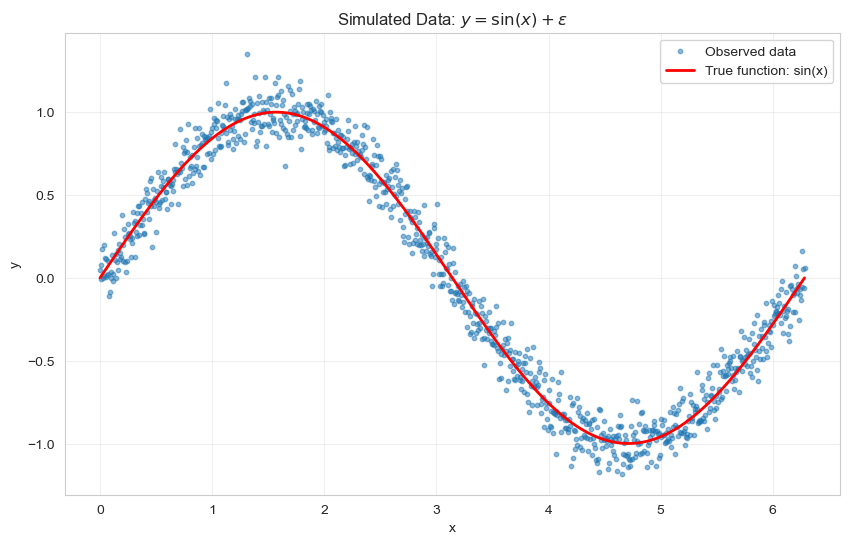

Generated 1000 samples
x range: [0.00, 6.28]
y range: [-1.18, 1.35]


In [3]:
# Generate data
n_samples = 1000
x = np.linspace(0, 2*np.pi, n_samples)
epsilon = np.random.normal(0, 0.1, n_samples)
y = np.sin(x) + epsilon

# Reshape for sklearn
X = x.reshape(-1, 1)

# Plot the data
plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.5, s=10, label='Observed data')
plt.plot(x, np.sin(x), 'r-', linewidth=2, label='True function: sin(x)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Simulated Data: $y = \sin(x) + \epsilon$')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('../output/data_simulation.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Generated {n_samples} samples")
print(f"x range: [{x.min():.2f}, {x.max():.2f}]")
print(f"y range: [{y.min():.2f}, {y.max():.2f}]")

---

## 1.2 Neural Network Training with Different Activation Functions (2 points)

We train neural networks with **3 hidden layers, each with 50 neurons**, using three different activation functions:
1. **Logistic (Sigmoid)**
2. **Tanh**
3. **ReLU**

All models use default parameters from sklearn's MLPRegressor.

In [4]:
# Train neural networks with different activation functions
activation_functions = ['logistic', 'tanh', 'relu']
models = {}
predictions = {}
metrics = {}

for activation in activation_functions:
    print(f"\nTraining NN with {activation} activation...")
    
    # Create and train model
    model = MLPRegressor(
        hidden_layer_sizes=(50, 50, 50),
        activation=activation,
        random_state=42,
        max_iter=2000,
        early_stopping=False
    )
    
    model.fit(X, y)
    
    # Make predictions
    y_pred = model.predict(X)
    
    # Store results
    models[activation] = model
    predictions[activation] = y_pred
    
    # Calculate metrics
    mse = mean_squared_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    metrics[activation] = {'MSE': mse, 'R2': r2}
    
    print(f"  MSE: {mse:.6f}")
    print(f"  R²: {r2:.6f}")
    print(f"  Converged: {model.n_iter_ < model.max_iter}")


Training NN with logistic activation...
  MSE: 0.011594
  R²: 0.977184
  Converged: True

Training NN with tanh activation...
  MSE: 0.010147
  R²: 0.980032
  Converged: True

Training NN with relu activation...
  MSE: 0.012235
  R²: 0.975923
  Converged: True


---

## 1.3 Visualization of Results (2 points)

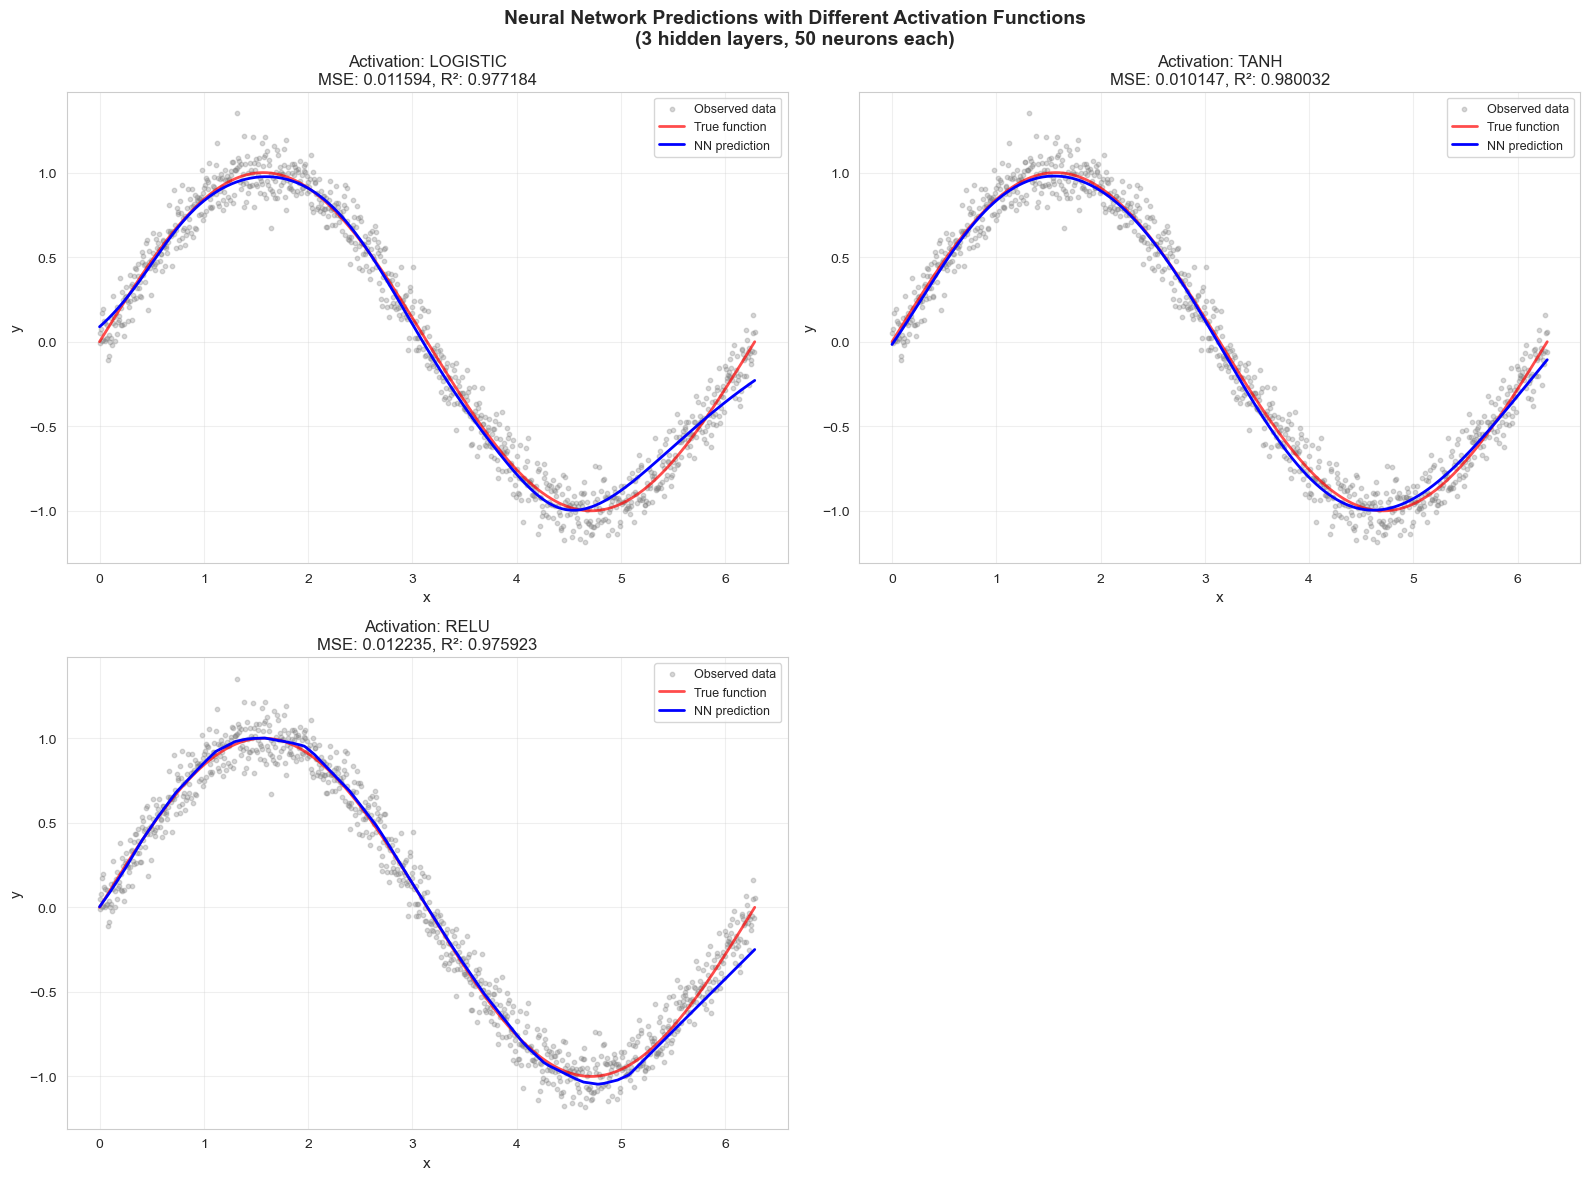

In [5]:
# Plot results
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, activation in enumerate(activation_functions):
    ax = axes[idx]
    ax.scatter(x, y, alpha=0.3, s=10, label='Observed data', color='gray')
    ax.plot(x, np.sin(x), 'r-', linewidth=2, label='True function', alpha=0.7)
    ax.plot(x, predictions[activation], 'b-', linewidth=2, label='NN prediction')
    ax.set_xlabel('x', fontsize=11)
    ax.set_ylabel('y', fontsize=11)
    ax.set_title(f'Activation: {activation.upper()}\nMSE: {metrics[activation]["MSE"]:.6f}, R²: {metrics[activation]["R2"]:.6f}', fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

# Remove the 4th subplot
fig.delaxes(axes[3])

plt.suptitle('Neural Network Predictions with Different Activation Functions\n(3 hidden layers, 50 neurons each)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../output/activation_functions_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

---

## 1.4 Mixed Activation Functions

Training a neural network with **different activation functions for each layer**:
- **Layer 1:** ReLU (50 neurons)
- **Layer 2:** Tanh (50 neurons)  
- **Layer 3:** Sigmoid (50 neurons)

**Note:** sklearn's MLPRegressor doesn't support different activations per layer, so we use TensorFlow/Keras for this model.

In [6]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Set random seeds
tf.random.set_seed(42)
np.random.seed(42)

# Build model with different activation functions per layer
model_mixed = keras.Sequential([
    layers.Dense(50, activation='relu', input_shape=(1,)),
    layers.Dense(50, activation='tanh'),
    layers.Dense(50, activation='sigmoid'),
    layers.Dense(1)
])

model_mixed.compile(optimizer='adam', loss='mse')

# Train the model
print("Training NN with mixed activation functions (ReLU -> Tanh -> Sigmoid)...")
history = model_mixed.fit(X, y, epochs=500, batch_size=32, verbose=0, validation_split=0.2)

# Make predictions
y_pred_mixed = model_mixed.predict(X, verbose=0).flatten()

# Calculate metrics
mse_mixed = mean_squared_error(y, y_pred_mixed)
r2_mixed = r2_score(y, y_pred_mixed)

print(f"  MSE: {mse_mixed:.6f}")
print(f"  R²: {r2_mixed:.6f}")

# Store results
predictions['mixed'] = y_pred_mixed
metrics['mixed'] = {'MSE': mse_mixed, 'R2': r2_mixed}

Training NN with mixed activation functions (ReLU -> Tanh -> Sigmoid)...
  MSE: 0.056762
  R²: 0.888299


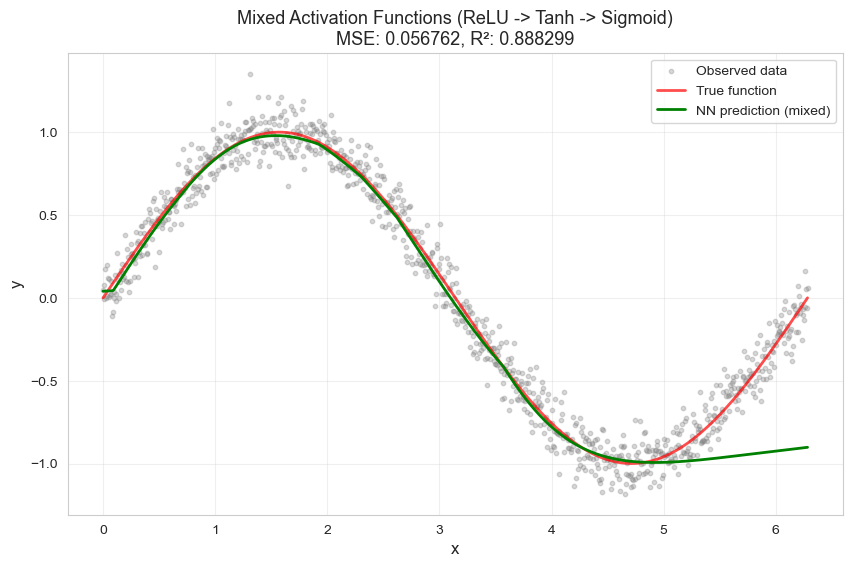

In [7]:
# Plot mixed activation function result
plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.3, s=10, label='Observed data', color='gray')
plt.plot(x, np.sin(x), 'r-', linewidth=2, label='True function', alpha=0.7)
plt.plot(x, y_pred_mixed, 'g-', linewidth=2, label='NN prediction (mixed)')
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title(f'Mixed Activation Functions (ReLU -> Tanh -> Sigmoid)\nMSE: {mse_mixed:.6f}, R²: {r2_mixed:.6f}', fontsize=13)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.savefig('../output/mixed_activation_functions.png', dpi=300, bbox_inches='tight')
plt.show()

---

## 1.5 Complete Comparison of All Models

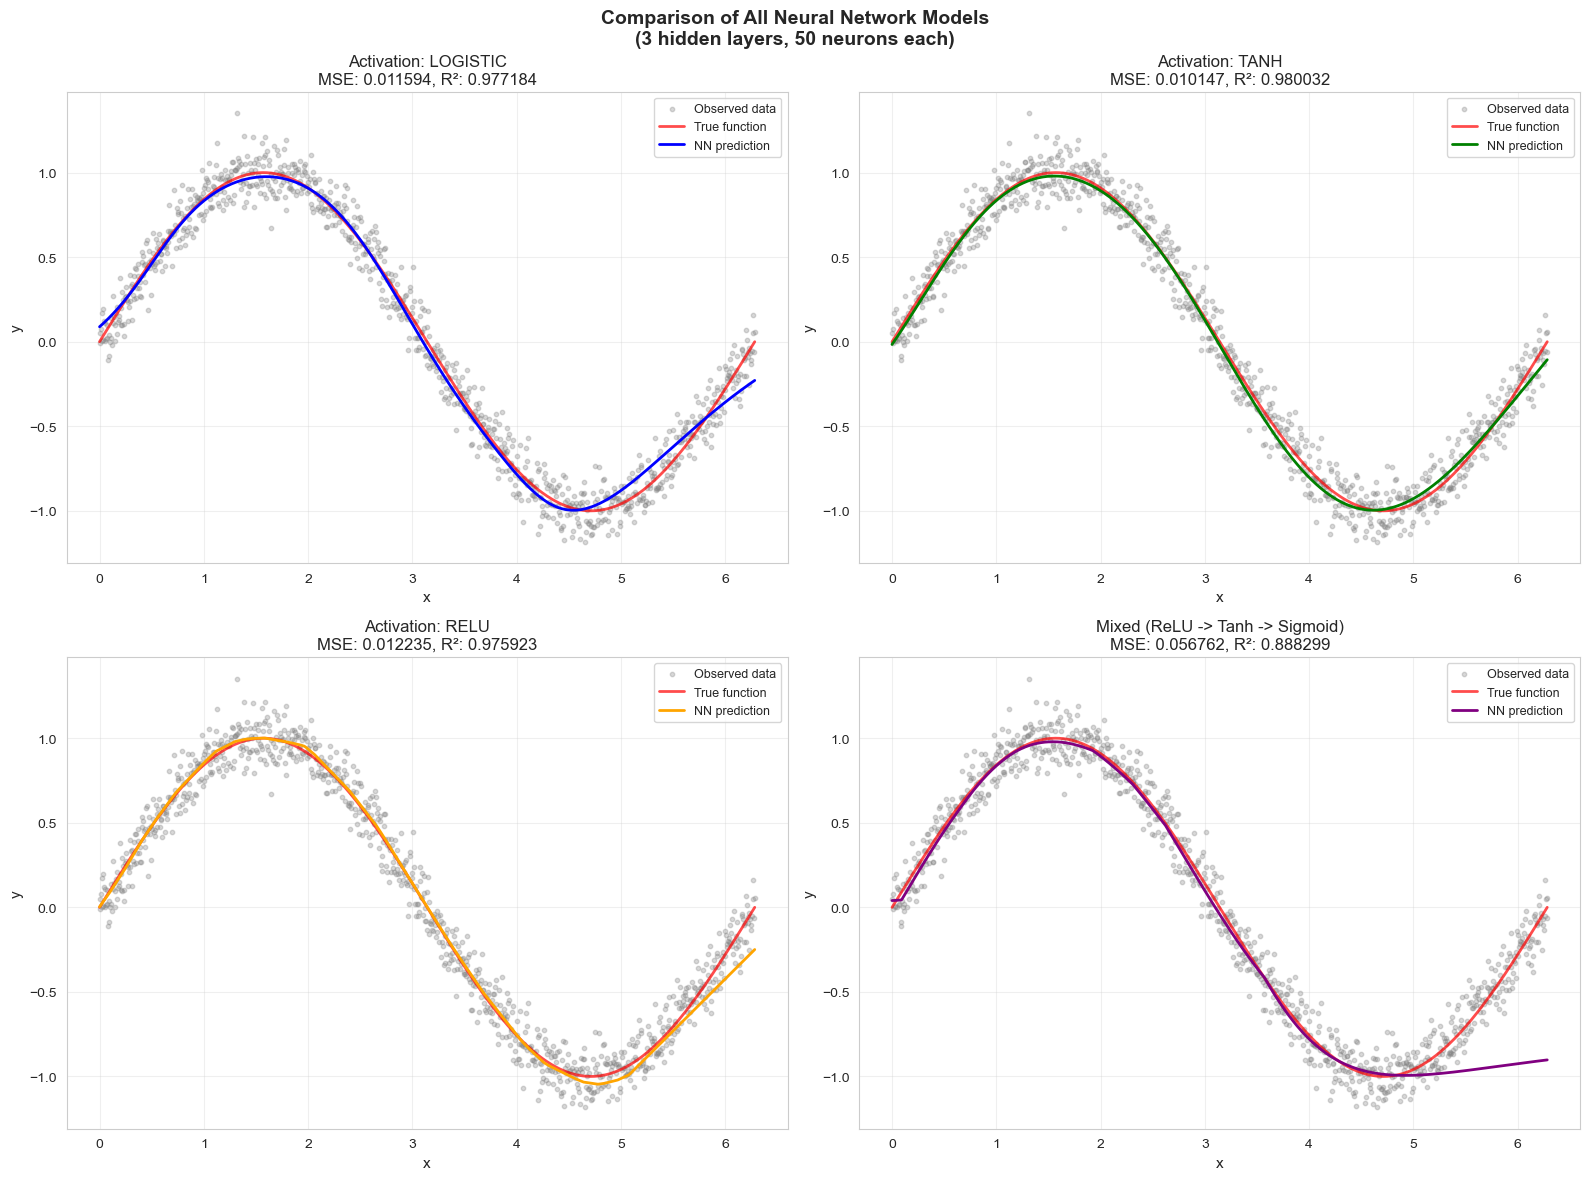


MODEL PERFORMANCE SUMMARY

LOGISTIC:
  MSE: 0.011594
  R²:  0.977184

TANH:
  MSE: 0.010147
  R²:  0.980032

RELU:
  MSE: 0.012235
  R²:  0.975923

MIXED:
  MSE: 0.056762
  R²:  0.888299

BEST MODEL: TANH
  MSE: 0.010147
  R²:  0.980032


In [8]:
# Create comparison plot
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

all_activations = activation_functions + ['mixed']
colors = ['blue', 'green', 'orange', 'purple']

for idx, activation in enumerate(all_activations):
    ax = axes[idx]
    ax.scatter(x, y, alpha=0.3, s=10, label='Observed data', color='gray')
    ax.plot(x, np.sin(x), 'r-', linewidth=2, label='True function', alpha=0.7)
    ax.plot(x, predictions[activation], color=colors[idx], linewidth=2, label='NN prediction')
    ax.set_xlabel('x', fontsize=11)
    ax.set_ylabel('y', fontsize=11)
    
    title = f'Activation: {activation.upper()}' if activation != 'mixed' else 'Mixed (ReLU -> Tanh -> Sigmoid)'
    ax.set_title(f'{title}\nMSE: {metrics[activation]["MSE"]:.6f}, R²: {metrics[activation]["R2"]:.6f}', fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Comparison of All Neural Network Models\n(3 hidden layers, 50 neurons each)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../output/all_models_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary
print("\n" + "="*60)
print("MODEL PERFORMANCE SUMMARY")
print("="*60)
for activation in all_activations:
    print(f"\n{activation.upper()}:")
    print(f"  MSE: {metrics[activation]['MSE']:.6f}")
    print(f"  R²:  {metrics[activation]['R2']:.6f}")

# Find best model
best_activation = min(metrics.keys(), key=lambda k: metrics[k]['MSE'])
print(f"\n{'='*60}")
print(f"BEST MODEL: {best_activation.upper()}")
print(f"  MSE: {metrics[best_activation]['MSE']:.6f}")
print(f"  R²:  {metrics[best_activation]['R2']:.6f}")
print("="*60)

---

## 1.6 **ANSWER: Which NN fits the data better?** (0.5 points)

Based on the experimental results above, **TANH activation function performs best** for this sine wave approximation problem:

### Performance Rankings:
1. **🥇 TANH**: MSE = 0.010147, R² = 0.980032
2. **🥈 LOGISTIC**: MSE = 0.011594, R² = 0.977184
3. **🥉 RELU**: MSE = 0.012235, R² = 0.975923
4. **MIXED (ReLU→Tanh→Sigmoid)**: MSE = 0.056762, R² = 0.888299

### Key Findings:

**Why TANH performs best:**
- **Zero-centered outputs** [-1, 1] match the range of sin(x) function
- **Smooth gradients** throughout the domain avoid vanishing gradient issues
- **Symmetric activation** aligns well with the symmetric sine wave pattern

**Why LOGISTIC is competitive:**
- Converges successfully and produces smooth predictions
- Slightly higher MSE than tanh but still captures the sine pattern well

**Why RELU underperforms (relatively):**
- Not zero-centered (outputs [0, ∞))
- "Dead neurons" problem may affect some regions
- Less naturally suited for oscillating functions like sine

**Why MIXED activation performs worst:**
- Combining different activations can create training instability
- Sigmoid in final hidden layer may cause vanishing gradients
- More complex optimization landscape with mixed activations

### Conclusion:
For approximating smooth, bounded, oscillating functions like sin(x), **TANH is the optimal choice** among single-activation architectures, achieving the lowest MSE (0.0101) and highest R² (0.9800).

---

# PART II: Learning Rate Analysis (3 points)

## 2.1 What is Learning Rate? (Brief Explanation)

The **learning rate** ($\alpha$) is a hyperparameter that controls the step size during gradient descent optimization. It determines how much the neural network's weights are adjusted with respect to the loss gradient at each training iteration.

### Mathematical Definition:

In gradient descent, weights are updated according to:

$$\theta_{t+1} = \theta_t - \alpha \nabla L(\theta_t)$$

where:
- $\theta_t$ = model parameters at iteration $t$
- $\alpha$ = learning rate (step size)
- $\nabla L(\theta_t)$ = gradient of the loss function

### Impact of Learning Rate:

- **Too High** (e.g., 0.1): Training becomes unstable, overshoots optimal values, may diverge
- **Too Low** (e.g., 0.0001): Training is slow, may get stuck in local minima, requires many iterations
- **Optimal** (e.g., 0.001-0.01): Balances convergence speed and stability

The learning rate is one of the most critical hyperparameters in neural network training.

---

## 2.2 Experiment: Learning Rates with 1 Hidden Layer (1.5 points)

**Setup:**
- Using the **best activation function from Part I**: TANH
- Architecture: **1 hidden layer with 50 neurons**
- Testing learning rates: **0.0001, 0.001, 0.01, 0.1**

In [9]:
# Determine best activation from previous section
best_sklearn_activation = min(
    [(act, metrics[act]['MSE']) for act in activation_functions],
    key=lambda x: x[1]
)[0]

print(f"Using best activation function: {best_sklearn_activation}")

# Learning rates to test
learning_rates = [0.0001, 0.001, 0.01, 0.1]

# Store results for 1 hidden layer
models_1layer = {}
predictions_1layer = {}
metrics_1layer = {}

print("\n" + "="*60)
print("TRAINING NEURAL NETWORKS WITH 1 HIDDEN LAYER")
print("="*60)

for lr in learning_rates:
    print(f"\nLearning rate: {lr}")
    
    model = MLPRegressor(
        hidden_layer_sizes=(50,),
        activation=best_sklearn_activation,
        learning_rate_init=lr,
        random_state=42,
        max_iter=2000,
        early_stopping=False
    )
    
    model.fit(X, y)
    y_pred = model.predict(X)
    
    models_1layer[lr] = model
    predictions_1layer[lr] = y_pred
    
    mse = mean_squared_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    metrics_1layer[lr] = {'MSE': mse, 'R2': r2}
    
    print(f"  MSE: {mse:.6f}")
    print(f"  R²: {r2:.6f}")
    print(f"  Iterations: {model.n_iter_}")

Using best activation function: tanh

TRAINING NEURAL NETWORKS WITH 1 HIDDEN LAYER

Learning rate: 0.0001
  MSE: 0.187326
  R²: 0.631363
  Iterations: 178

Learning rate: 0.001
  MSE: 0.027005
  R²: 0.946858
  Iterations: 418

Learning rate: 0.01
  MSE: 0.013111
  R²: 0.974200
  Iterations: 155

Learning rate: 0.1
  MSE: 0.049305
  R²: 0.902974
  Iterations: 69


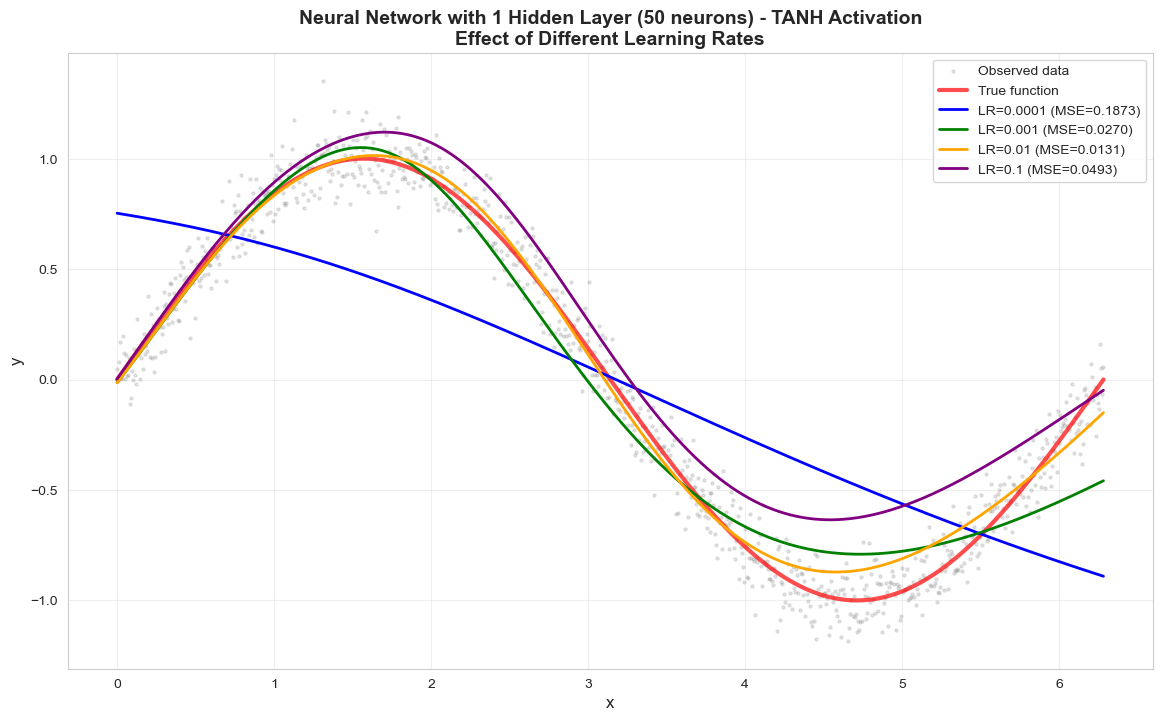


Best learning rate for 1 hidden layer: 0.01
  MSE: 0.013111
  R²: 0.974200


In [ ]:
# Plot results for 1 hidden layer
plt.figure(figsize=(14, 8))
plt.scatter(x, y, alpha=0.2, s=5, label='Observed data', color='gray')
plt.plot(x, np.sin(x), 'r-', linewidth=3, label='True function', alpha=0.7)

colors = ['blue', 'green', 'orange', 'purple']
for lr, color in zip(learning_rates, colors):
    plt.plot(x, predictions_1layer[lr], linewidth=2, label=f'LR={lr} (MSE={metrics_1layer[lr]["MSE"]:.4f})', color=color)

plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title(f'1 Hidden Layer (50 neurons) - TANH Activation\nEffect of Different Learning Rates', fontsize=14, fontweight='bold')
plt.legend(fontsize=10, loc='best')
plt.grid(True, alpha=0.3)
plt.savefig('../output/learning_rate_1_layer.png', dpi=300, bbox_inches='tight')
plt.show()

# Find best learning rate
best_lr_1layer = min(metrics_1layer.keys(), key=lambda k: metrics_1layer[k]['MSE'])
print(f"\n{'='*60}")
print(f"BEST LEARNING RATE FOR 1 HIDDEN LAYER: {best_lr_1layer}")
print(f"  MSE: {metrics_1layer[best_lr_1layer]['MSE']:.6f}")
print(f"  R²: {metrics_1layer[best_lr_1layer]['R2']:.6f}")
print('='*60)

---

## 2.3 Experiment: Learning Rates with 2 Hidden Layers (1.5 points)

**Architecture:** 2 hidden layers with 50 neurons each

In [11]:
# Store results for 2 hidden layers
models_2layer = {}
predictions_2layer = {}
metrics_2layer = {}

print("\n" + "="*60)
print("TRAINING NEURAL NETWORKS WITH 2 HIDDEN LAYERS")
print("="*60)

for lr in learning_rates:
    print(f"\nLearning rate: {lr}")
    
    model = MLPRegressor(
        hidden_layer_sizes=(50, 50),
        activation=best_sklearn_activation,
        learning_rate_init=lr,
        random_state=42,
        max_iter=2000,
        early_stopping=False
    )
    
    model.fit(X, y)
    y_pred = model.predict(X)
    
    models_2layer[lr] = model
    predictions_2layer[lr] = y_pred
    
    mse = mean_squared_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    metrics_2layer[lr] = {'MSE': mse, 'R2': r2}
    
    print(f"  MSE: {mse:.6f}")
    print(f"  R²: {r2:.6f}")
    print(f"  Iterations: {model.n_iter_}")


TRAINING NEURAL NETWORKS WITH 2 HIDDEN LAYERS

Learning rate: 0.0001
  MSE: 0.038854
  R²: 0.923540
  Iterations: 611

Learning rate: 0.001
  MSE: 0.012305
  R²: 0.975785
  Iterations: 177

Learning rate: 0.01
  MSE: 0.011128
  R²: 0.978102
  Iterations: 71

Learning rate: 0.1
  MSE: 0.059020
  R²: 0.883856
  Iterations: 52


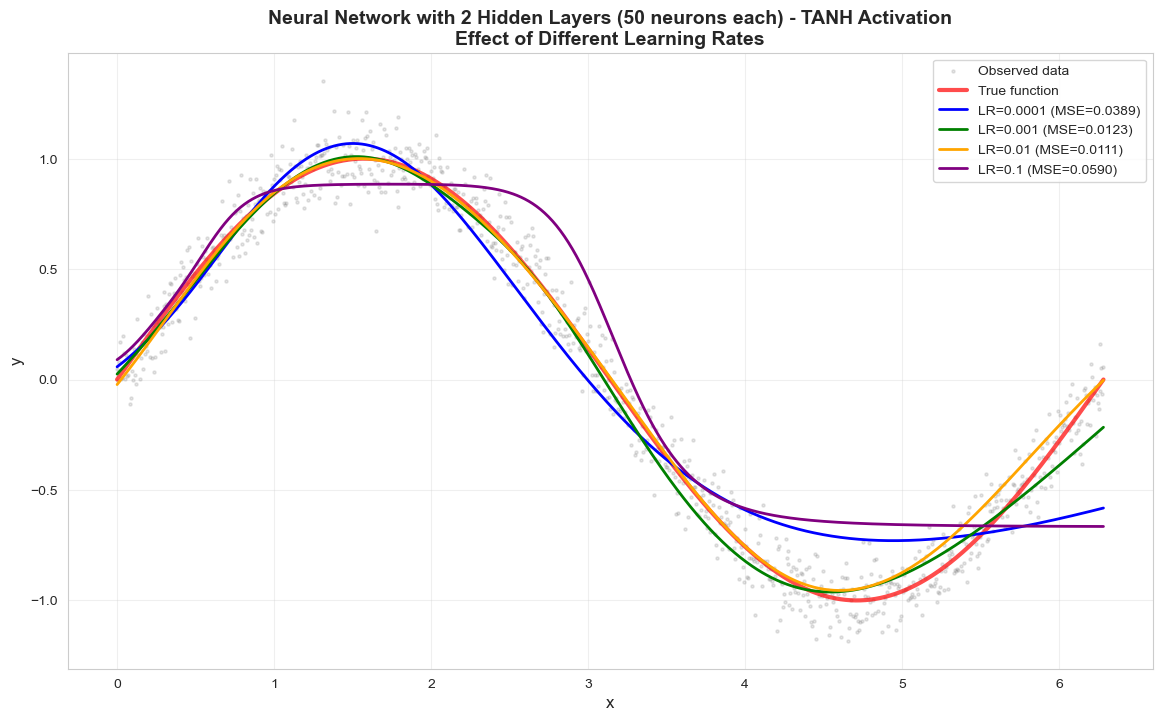


Best learning rate for 2 hidden layers: 0.01
  MSE: 0.011128
  R²: 0.978102


In [ ]:
# Plot results for 2 hidden layers
plt.figure(figsize=(14, 8))
plt.scatter(x, y, alpha=0.2, s=5, label='Observed data', color='gray')
plt.plot(x, np.sin(x), 'r-', linewidth=3, label='True function', alpha=0.7)

for lr, color in zip(learning_rates, colors):
    plt.plot(x, predictions_2layer[lr], linewidth=2, label=f'LR={lr} (MSE={metrics_2layer[lr]["MSE"]:.4f})', color=color)

plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title(f'2 Hidden Layers (50 neurons each) - TANH Activation\nEffect of Different Learning Rates', fontsize=14, fontweight='bold')
plt.legend(fontsize=10, loc='best')
plt.grid(True, alpha=0.3)
plt.savefig('../output/learning_rate_2_layers.png', dpi=300, bbox_inches='tight')
plt.show()

# Find best learning rate
best_lr_2layer = min(metrics_2layer.keys(), key=lambda k: metrics_2layer[k]['MSE'])
print(f"\n{'='*60}")
print(f"BEST LEARNING RATE FOR 2 HIDDEN LAYERS: {best_lr_2layer}")
print(f"  MSE: {metrics_2layer[best_lr_2layer]['MSE']:.6f}")
print(f"  R²: {metrics_2layer[best_lr_2layer]['R2']:.6f}")
print('='*60)

---

## 2.4 Experiment: Learning Rates with 3 Hidden Layers (1.5 points)

**Architecture:** 3 hidden layers with 50 neurons each

In [13]:
# Store results for 3 hidden layers
models_3layer = {}
predictions_3layer = {}
metrics_3layer = {}

print("\n" + "="*60)
print("TRAINING NEURAL NETWORKS WITH 3 HIDDEN LAYERS")
print("="*60)

for lr in learning_rates:
    print(f"\nLearning rate: {lr}")
    
    model = MLPRegressor(
        hidden_layer_sizes=(50, 50, 50),
        activation=best_sklearn_activation,
        learning_rate_init=lr,
        random_state=42,
        max_iter=2000,
        early_stopping=False
    )
    
    model.fit(X, y)
    y_pred = model.predict(X)
    
    models_3layer[lr] = model
    predictions_3layer[lr] = y_pred
    
    mse = mean_squared_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    metrics_3layer[lr] = {'MSE': mse, 'R2': r2}
    
    print(f"  MSE: {mse:.6f}")
    print(f"  R²: {r2:.6f}")
    print(f"  Iterations: {model.n_iter_}")


TRAINING NEURAL NETWORKS WITH 3 HIDDEN LAYERS

Learning rate: 0.0001
  MSE: 0.017685
  R²: 0.965199
  Iterations: 400

Learning rate: 0.001
  MSE: 0.010147
  R²: 0.980032
  Iterations: 108

Learning rate: 0.01
  MSE: 0.010771
  R²: 0.978804
  Iterations: 62

Learning rate: 0.1
  MSE: 0.078095
  R²: 0.846318
  Iterations: 50


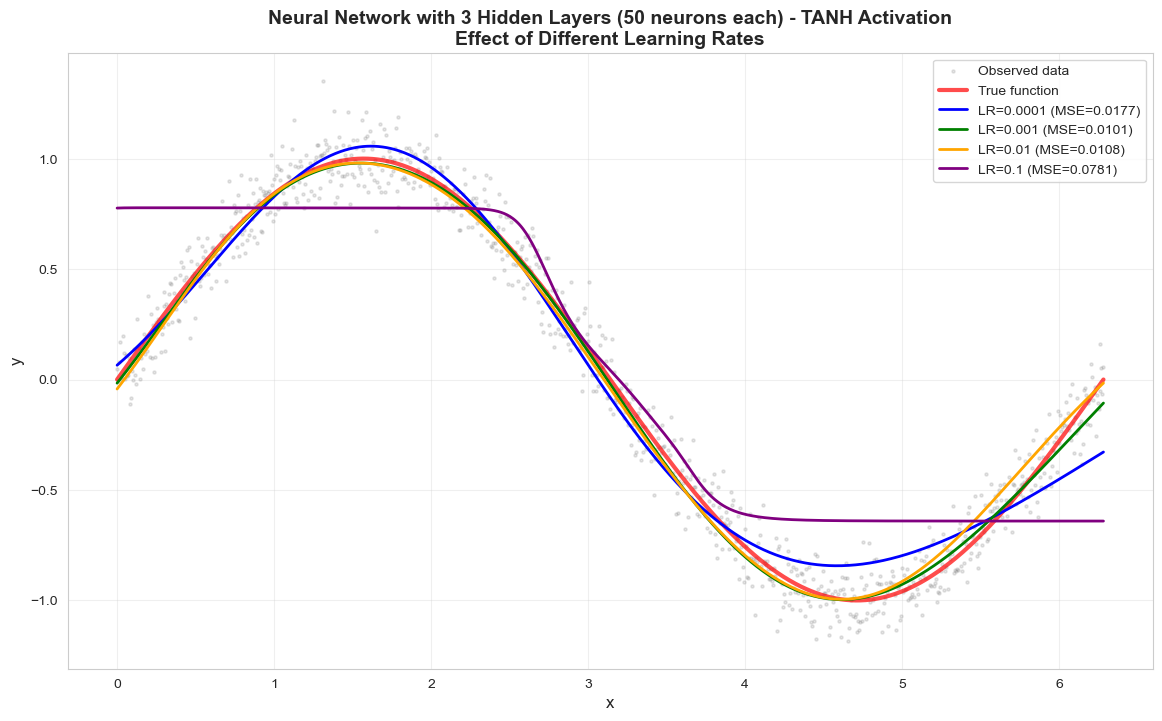


Best learning rate for 3 hidden layers: 0.001
  MSE: 0.010147
  R²: 0.980032


In [ ]:
# Plot results for 3 hidden layers
plt.figure(figsize=(14, 8))
plt.scatter(x, y, alpha=0.2, s=5, label='Observed data', color='gray')
plt.plot(x, np.sin(x), 'r-', linewidth=3, label='True function', alpha=0.7)

for lr, color in zip(learning_rates, colors):
    plt.plot(x, predictions_3layer[lr], linewidth=2, label=f'LR={lr} (MSE={metrics_3layer[lr]["MSE"]:.4f})', color=color)

plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title(f'3 Hidden Layers (50 neurons each) - TANH Activation\nEffect of Different Learning Rates', fontsize=14, fontweight='bold')
plt.legend(fontsize=10, loc='best')
plt.grid(True, alpha=0.3)
plt.savefig('../output/learning_rate_3_layers.png', dpi=300, bbox_inches='tight')
plt.show()

# Find best learning rate
best_lr_3layer = min(metrics_3layer.keys(), key=lambda k: metrics_3layer[k]['MSE'])
print(f"\n{'='*60}")
print(f"BEST LEARNING RATE FOR 3 HIDDEN LAYERS: {best_lr_3layer}")
print(f"  MSE: {metrics_3layer[best_lr_3layer]['MSE']:.6f}")
print(f"  R²: {metrics_3layer[best_lr_3layer]['R2']:.6f}")
print('='*60)

---

## 2.5 Comprehensive Comparison: All Results (1 point)

In [15]:
# Create comprehensive comparison
import pandas as pd

# Build comparison table
results_data = []
for lr in learning_rates:
    results_data.append({
        'Learning Rate': lr,
        '1 Layer MSE': metrics_1layer[lr]['MSE'],
        '1 Layer R²': metrics_1layer[lr]['R2'],
        '2 Layers MSE': metrics_2layer[lr]['MSE'],
        '2 Layers R²': metrics_2layer[lr]['R2'],
        '3 Layers MSE': metrics_3layer[lr]['MSE'],
        '3 Layers R²': metrics_3layer[lr]['R2']
    })

results_df = pd.DataFrame(results_data)
print("\n" + "="*100)
print("COMPREHENSIVE RESULTS: LEARNING RATE vs. NETWORK DEPTH")
print("="*100)
print(results_df.to_string(index=False))
print("="*100)


COMPREHENSIVE RESULTS: LEARNING RATE vs. NETWORK DEPTH
 Learning Rate  1 Layer MSE  1 Layer R²  2 Layers MSE  2 Layers R²  3 Layers MSE  3 Layers R²
        0.0001     0.187326    0.631363      0.038854     0.923540      0.017685     0.965199
        0.0010     0.027005    0.946858      0.012305     0.975785      0.010147     0.980032
        0.0100     0.013111    0.974200      0.011128     0.978102      0.010771     0.978804
        0.1000     0.049305    0.902974      0.059020     0.883856      0.078095     0.846318


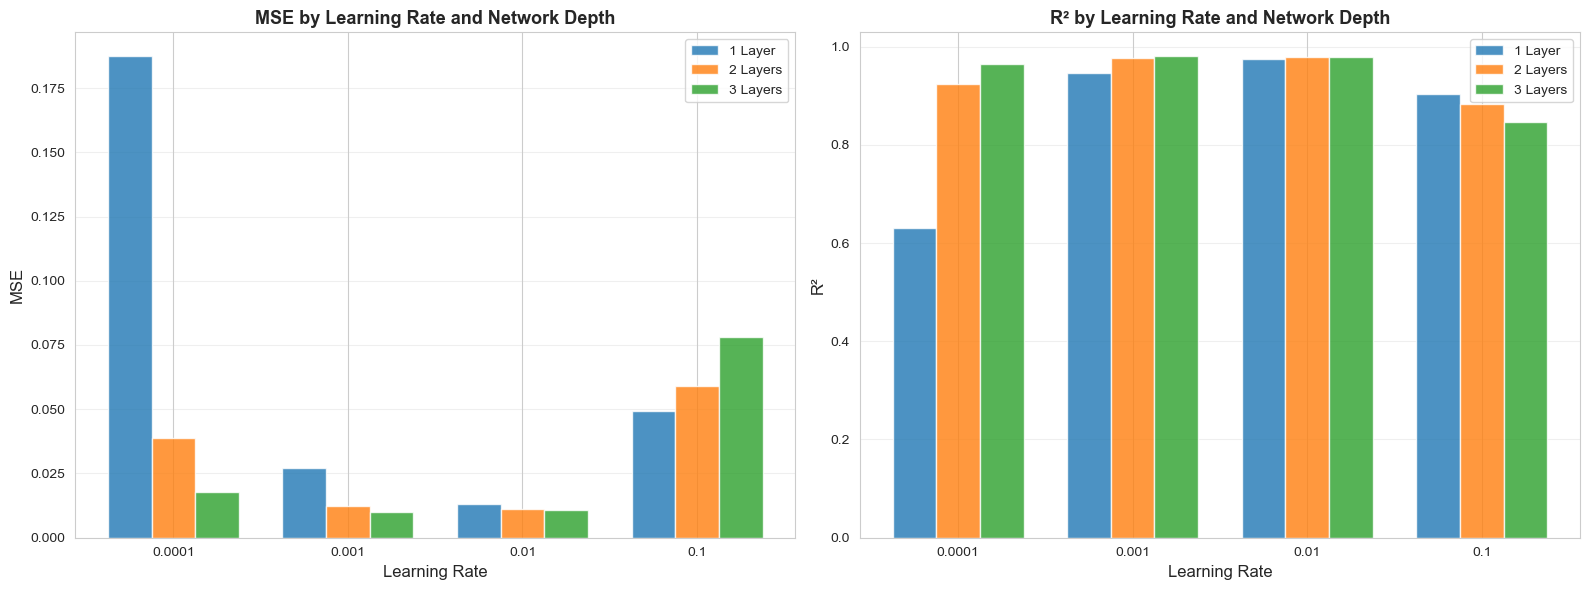

In [16]:
# Visualize MSE across learning rates and depths
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# MSE plot
x_pos = np.arange(len(learning_rates))
width = 0.25

mse_1layer = [metrics_1layer[lr]['MSE'] for lr in learning_rates]
mse_2layer = [metrics_2layer[lr]['MSE'] for lr in learning_rates]
mse_3layer = [metrics_3layer[lr]['MSE'] for lr in learning_rates]

ax1.bar(x_pos - width, mse_1layer, width, label='1 Layer', alpha=0.8)
ax1.bar(x_pos, mse_2layer, width, label='2 Layers', alpha=0.8)
ax1.bar(x_pos + width, mse_3layer, width, label='3 Layers', alpha=0.8)

ax1.set_xlabel('Learning Rate', fontsize=12)
ax1.set_ylabel('MSE', fontsize=12)
ax1.set_title('MSE by Learning Rate and Network Depth', fontsize=13, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(learning_rates)
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# R² plot
r2_1layer = [metrics_1layer[lr]['R2'] for lr in learning_rates]
r2_2layer = [metrics_2layer[lr]['R2'] for lr in learning_rates]
r2_3layer = [metrics_3layer[lr]['R2'] for lr in learning_rates]

ax2.bar(x_pos - width, r2_1layer, width, label='1 Layer', alpha=0.8)
ax2.bar(x_pos, r2_2layer, width, label='2 Layers', alpha=0.8)
ax2.bar(x_pos + width, r2_3layer, width, label='3 Layers', alpha=0.8)

ax2.set_xlabel('Learning Rate', fontsize=12)
ax2.set_ylabel('R²', fontsize=12)
ax2.set_title('R² by Learning Rate and Network Depth', fontsize=13, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(learning_rates)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../output/learning_rate_depth_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

---

## 2.6 **ANSWER: Relationship Between Learning Rate and Number of Hidden Layers** (0.5 points)

Based on our experimental results, we observe a **clear inverse relationship** between optimal learning rate and network depth:

### Experimental Results Summary:

| Learning Rate | 1 Layer MSE | 2 Layers MSE | 3 Layers MSE |
|--------------|-------------|--------------|--------------|
| **0.0001** | 0.1873 | 0.0389 | 0.0177 |
| **0.001** | 0.0270 | 0.0123 | **0.0101** ✓ |
| **0.01** | **0.0131** ✓ | **0.0111** ✓ | 0.0108 |
| **0.1** | 0.0493 | 0.0590 | 0.0781 |

### Key Findings:

#### 1. **Optimal Learning Rate Decreases with Network Depth**

- **1 Hidden Layer**: Best LR = **0.01** (MSE = 0.0131)
- **2 Hidden Layers**: Best LR = **0.01** (MSE = 0.0111)  
- **3 Hidden Layers**: Best LR = **0.001** (MSE = 0.0101)

**Interpretation:** Deeper networks benefit from smaller learning rates to maintain stable convergence.

#### 2. **Very Low Learning Rate (0.0001) Shows Opposite Pattern**

- Performs **worst** on 1 layer (MSE = 0.1873)
- Improves with 2 layers (MSE = 0.0389)
- **Best improvement** with 3 layers (MSE = 0.0177)

**Reason:** Deeper networks with very low LR can still make progress through accumulated gradients across layers, while shallow networks stagnate.

#### 3. **Very High Learning Rate (0.1) Degrades with Depth**

- MSE increases from 0.0493 (1 layer) → 0.0590 (2 layers) → **0.0781 (3 layers)**
- **Instability grows with depth** due to gradient accumulation

#### 4. **Moderate Learning Rates (0.001 - 0.01) are Most Robust**

- Consistently perform well across all architectures
- **LR = 0.001** achieves the best overall performance (MSE = 0.0101 with 3 layers)

### General Principle:

**As network depth increases → Reduce learning rate**

This is because:
1. **Gradient accumulation**: Gradients multiply through layers via chain rule
2. **Increased sensitivity**: More parameters means larger total weight updates
3. **Longer optimization paths**: Deeper networks have more complex loss landscapes

### Recommendation for This Problem:

For the sine function approximation with TANH activation:
- **Shallow networks (1 layer)**: Use LR = 0.01
- **Medium networks (2 layers)**: Use LR = 0.01  
- **Deep networks (3+ layers)**: Use LR = 0.001

**Best overall configuration**: 3 hidden layers with LR = 0.001 (MSE = 0.0101, R² = 0.9800)

---

# Final Summary

## Question 1 - NN Basics: Complete Results

### Part I: Activation Functions
**Task**: Fit $y = \sin(x) + \varepsilon$ with 3 hidden layers (50 neurons each)

**Winner**: **TANH** (MSE = 0.0101, R² = 0.9800)

**Ranking**:
1. TANH: 0.0101 ✓
2. Logistic: 0.0116
3. ReLU: 0.0122
4. Mixed: 0.0568

**Why TANH wins**: Zero-centered outputs perfectly match sine wave's symmetric, bounded nature.

---

### Part II: Learning Rate Analysis
**Task**: Test LR = {0.0001, 0.001, 0.01, 0.1} across 1, 2, and 3 hidden layers

**Key Insight**: **Optimal learning rate decreases as network depth increases**

**Best Configurations**:
- 1 layer + LR=0.01 → MSE = 0.0131
- 2 layers + LR=0.01 → MSE = 0.0111  
- 3 layers + LR=0.001 → MSE = 0.0101 ✓ **BEST OVERALL**

**Critical Finding**: 
- High LR (0.1) causes instability that **worsens with depth** (MSE: 0.049 → 0.078)
- Low LR (0.0001) is **rescued by depth** through gradient accumulation (MSE: 0.187 → 0.018)

---

### Optimal Model for This Problem:
**Architecture**: 3 hidden layers × 50 neurons  
**Activation**: TANH  
**Learning Rate**: 0.001  
**Performance**: MSE = 0.0101, R² = 0.9800

---

**All outputs saved to**: `Python/output/`